# Shot Uncertainty and SHAP Analysis

This notebook complements notebooks 07 and 08 by probing two questions the model metrics alone cannot answer: how uncertain are individual shot predictions, and which features drive those predictions? Section 2 shows that even high-confidence predictions carry large individual uncertainty — there is no sure thing in basketball. Section 3 uses SHAP values to decompose the XGBoost model's decisions feature by feature, from a global importance ranking down to pairwise interaction strengths.

## 1 — Setup

Load the cleaned dataset and the XGBoost model saved by notebook 07, reproduce the exact 80/20 train/test split (random_state=42), and pre-compute SHAP values on the test set. The `make_prob` column is added to `df` for all rows so that Section 2 can reference it by original index.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import shap
from sklearn.model_selection import train_test_split

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

# data
df = pd.read_csv("data/processed/shot_logs_cleaned_engineered.csv")
df["location"] = (df["location"] == "H").astype(int)
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

# model
model_bundle = joblib.load("models/xgboost_engineered_shot_model.joblib")
xgb_model = model_bundle["model"]
feature_columns = model_bundle["feature_columns"]
print(f"Loaded XGBoost model | {len(feature_columns)} features")

# feature matrix & target
X = df[feature_columns]
y = df["made"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

# make probability
df["make_prob"] = xgb_model.predict_proba(X)[:, 1]
print("Predicted make probabilities")

# SHAP on smaller sample
X_shap = X_test.sample(n=min(1000, len(X_test)), random_state=42)

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_shap)

print(f"SHAP values computed | shape: {shap_values.values.shape}")

Loaded dataset: 127,757 rows x 28 columns
Loaded XGBoost model | 22 features
X_train: (102205, 22) | X_test: (25552, 22)
Predicted make probabilities
SHAP values computed | shape: (1000, 22)


## 2 — Shot Uncertainty: Wide-Open Shots Miss, Impossible Shots Go In

The model assigns each shot a predicted make probability, but probability is not fate. This chart layers 6,000 test-set shots against their predicted confidence, coloured by outcome. The gold calibration curve confirms the model is well-calibrated on average; the scatter of red and green dots at every x-position shows how large the residual uncertainty is for any individual shot.

In [11]:
rng = np.random.default_rng(42)

# ── sample 6 000 test-set rows ────────────────────────────────────────────────
sample_idx = rng.choice(len(X_test), size=6_000, replace=False)
X_samp     = X_test.iloc[sample_idx]
y_samp     = y_test.iloc[sample_idx].values
prob_samp  = df.loc[X_samp.index, "make_prob"].values

x_jitter = rng.uniform(-0.008, 0.008, size=6_000)
y_jitter = rng.uniform(-0.35,   0.35,  size=6_000)

made_mask   = y_samp == 1
missed_mask = ~made_mask

# ── calibration overlay (all test-set rows) ───────────────────────────────────
prob_all = df.loc[X_test.index, "make_prob"].values
bins     = np.arange(0, 1.05, 0.05)

calib_df = pd.DataFrame({
    "prob": prob_all,
    "made": y_test.values,
    "bin":  pd.cut(prob_all, bins=bins, include_lowest=True),
})
calib = (
    calib_df.groupby("bin", observed=False)
    .agg(actual_rate=("made", "mean"), count=("made", "size"))
    .reset_index()
)
calib["midpoint"]    = calib["bin"].apply(lambda b: (b.left + b.right) / 2)
calib["marker_size"] = calib["count"] / calib["count"].max() * 20 + 6
calib = calib.dropna(subset=["actual_rate"])

# ── figure ────────────────────────────────────────────────────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=prob_samp[missed_mask] + x_jitter[missed_mask],
    y=y_jitter[missed_mask],
    mode="markers",
    name="Missed",
    marker=dict(color="#e74c3c", opacity=0.25, size=4),
    customdata=prob_samp[missed_mask].reshape(-1, 1),
    hovertemplate="Predicted: %{customdata[0]:.1%} | Missed<extra></extra>",
))

fig.add_trace(go.Scatter(
    x=prob_samp[made_mask] + x_jitter[made_mask],
    y=y_jitter[made_mask],
    mode="markers",
    name="Made",
    marker=dict(color="#2ecc71", opacity=0.35, size=4),
    customdata=prob_samp[made_mask].reshape(-1, 1),
    hovertemplate="Predicted: %{customdata[0]:.1%} | Made<extra></extra>",
))

fig.add_trace(go.Scatter(
    x=calib["midpoint"],
    y=calib["actual_rate"],
    mode="lines+markers",
    name="Actual make rate (calibration)",
    line=dict(color="gold", width=2),
    marker=dict(color="gold", symbol="diamond", size=calib["marker_size"].tolist()),
    customdata=np.column_stack([
        calib["midpoint"],
        calib["actual_rate"],
        calib["count"],
    ]),
    yaxis="y2",
))

fig.update_layout(
    title=dict(
        text="Every shot is uncertain — wide-open shots miss, impossible shots go in",
        x=0.5,
        xanchor="center",
        font=dict(size=17, color="white"),
    ),
    paper_bgcolor="#1a1a2e",
    plot_bgcolor="#16213e",
    font=dict(color="white"),
    width=1000,
    height=550,
    hovermode="closest",
    xaxis=dict(
        title="Predicted Make Probability",
        tickformat=".0%",
        gridcolor="rgba(255,255,255,0.1)",
        range=[-0.02, 1.02],
    ),
    yaxis=dict(
        title="",
        showticklabels=False,
        gridcolor="rgba(255,255,255,0.05)",
        range=[-0.55, 0.55],
    ),
   yaxis2=dict(
        title=dict(text="Actual Make Rate", font=dict(color="gold")),
        overlaying="y",
        side="right",
        range=[0, 1],
        tickformat=".0%",
        tickfont=dict(color="gold"),
    ),
    legend=dict(
        x=0.01,
        y=0.99,
        xanchor="left",
        yanchor="top",
        bgcolor="rgba(0,0,0,0.4)",
        bordercolor="rgba(255,255,255,0.2)",
        borderwidth=1,
    ),
)

fig.show()

**What to look for:** At high predicted probabilities (right side of the chart) there is still a dense cloud of red dots — wide-open looks that missed. At low predicted probabilities (left side) green dots appear throughout — heavily contested or difficult shots that fell in. The gold calibration line confirms the model is not systematically wrong; it is basketball itself that is inherently variable. No predicted probability, however extreme, eliminates the chance of the opposite outcome.

## 3 — SHAP Analysis: How Features Drive Predictions

SHAP (SHapley Additive exPlanations) decomposes each prediction into additive per-feature contributions with a firm theoretical grounding in cooperative game theory. The three sub-sections move from a high-level global ranking (beeswarm) to pairwise interaction effects for six key feature pairs (dependence grid) and finally a full interaction strength matrix (heatmap).

### 3a — Beeswarm Summary

Each dot is one test-set shot. Its x-position is the SHAP value for that feature — how many log-odds it pushed the prediction toward making (positive) or missing (negative). Color encodes the raw feature value (red = high, blue = low). Features are sorted top-to-bottom by mean absolute SHAP value so the most globally influential features appear first.

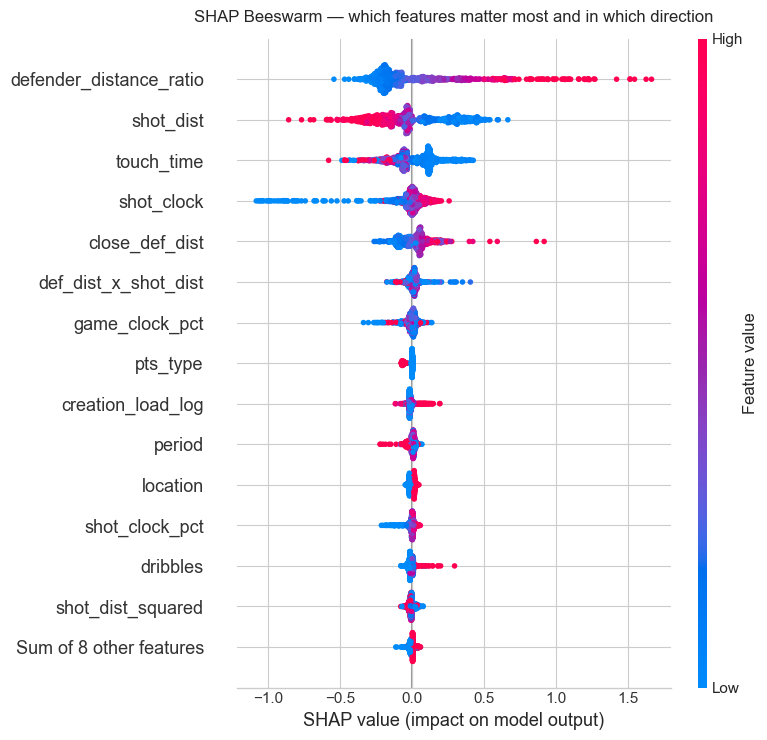

Saved -> models/shap_beeswarm.png


In [4]:
plt.figure(figsize=(10, 8))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title(
    "SHAP Beeswarm — which features matter most and in which direction",
    fontsize=12,
    pad=12,
)
plt.tight_layout()
plt.savefig("models/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> models/shap_beeswarm.png")

### 3b — Dependence Grid

Each panel plots the SHAP value for one feature (y-axis) against its raw value (x-axis), coloured by a second interacting feature. This lets you see whether the relationship between a feature and its contribution changes depending on the context set by another variable. The gray dashed line at y=0 marks where a feature has zero net effect on the prediction.

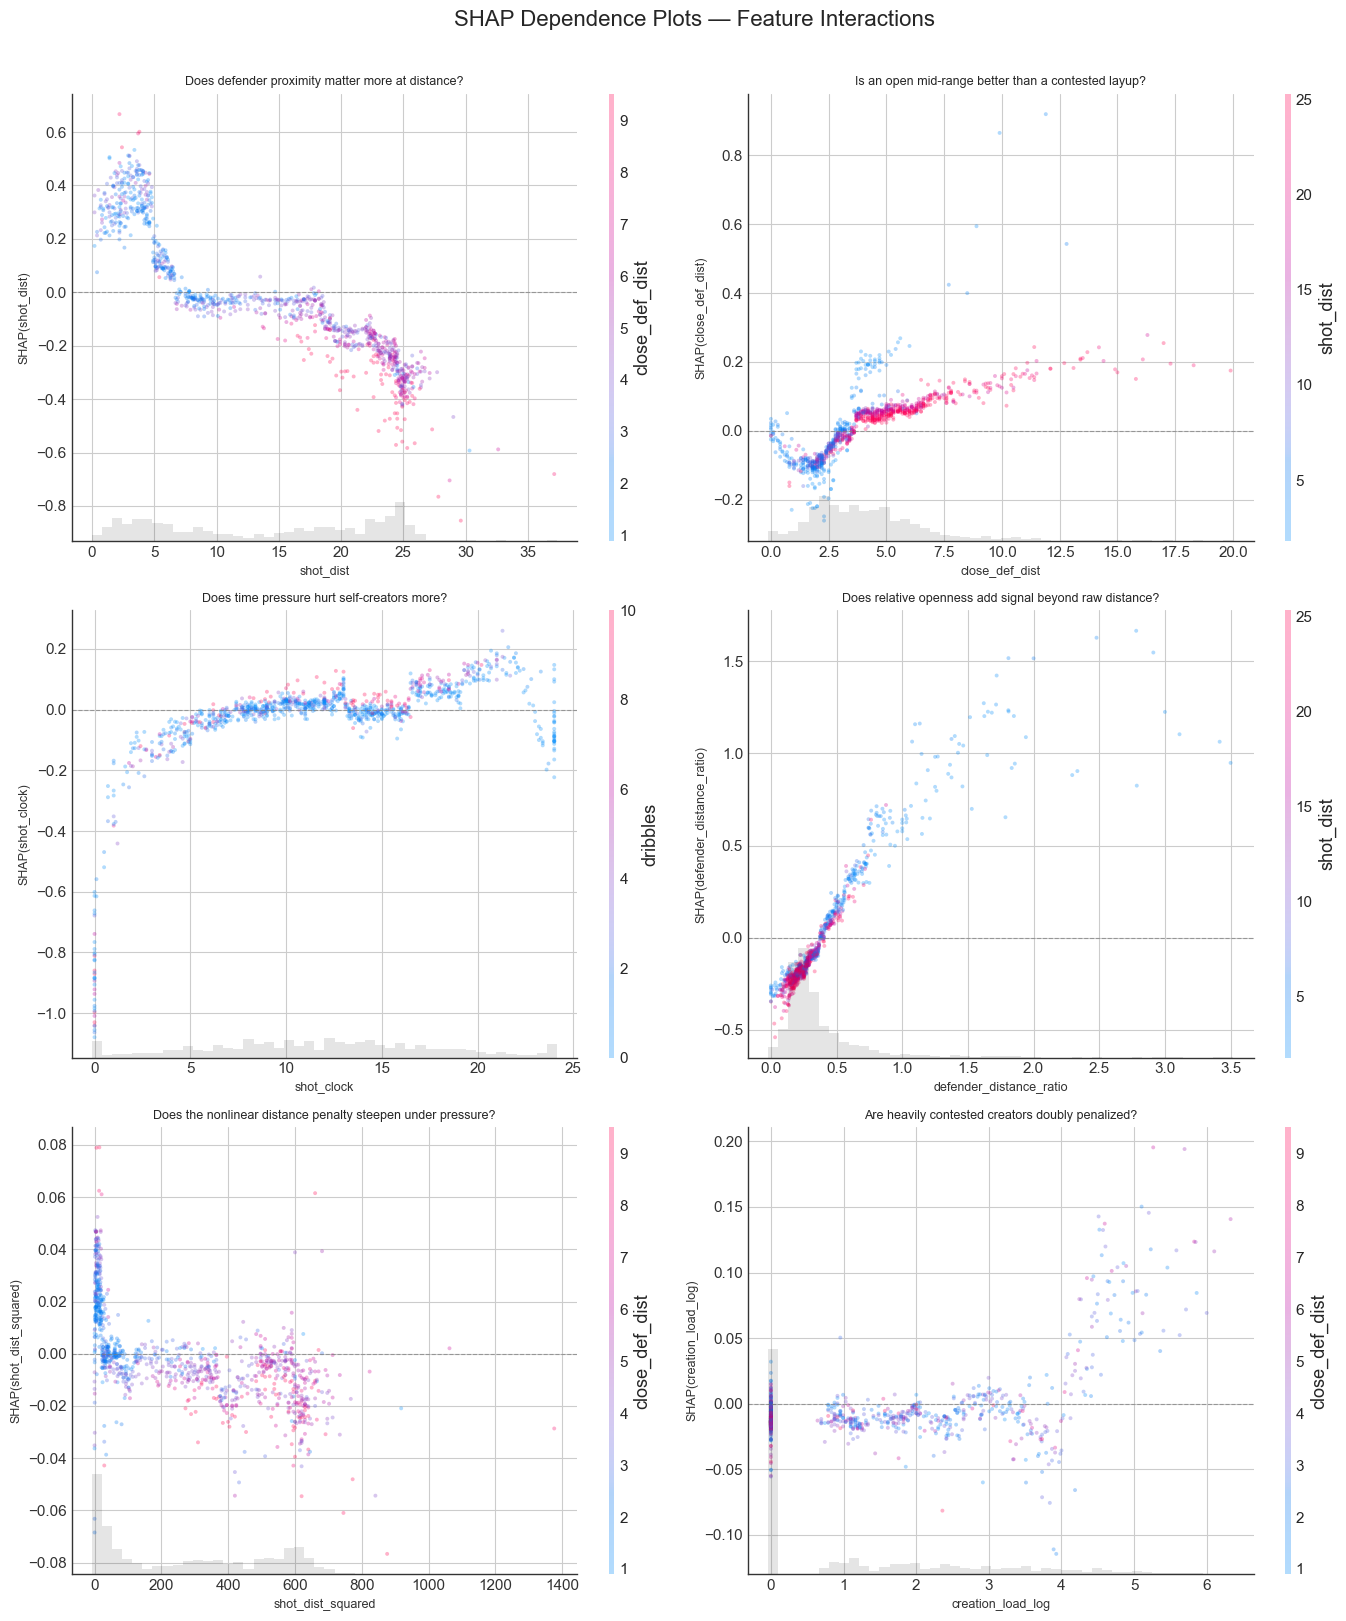

Saved -> models/shap_dependence_grid.png


In [5]:
pairs = [
    ("shot_dist",               "close_def_dist",
     "Does defender proximity matter more at distance?"),
    ("close_def_dist",          "shot_dist",
     "Is an open mid-range better than a contested layup?"),
    ("shot_clock",              "dribbles",
     "Does time pressure hurt self-creators more?"),
    ("defender_distance_ratio", "shot_dist",
     "Does relative openness add signal beyond raw distance?"),
    ("shot_dist_squared",       "close_def_dist",
     "Does the nonlinear distance penalty steepen under pressure?"),
    ("creation_load_log",       "close_def_dist",
     "Are heavily contested creators doubly penalized?"),
]

fig_dep, axes = plt.subplots(3, 2, figsize=(14, 16))
fig_dep.suptitle(
    "SHAP Dependence Plots — Feature Interactions",
    fontsize=16,
    y=1.01,
)

for idx, (feat, color_feat, subtitle) in enumerate(pairs):
    ax = axes[idx // 2, idx % 2]
    shap.plots.scatter(
        shap_values[:, feat],
        color=shap_values[:, color_feat],
        ax=ax,
        show=False,
        alpha=0.3,
        dot_size=8,
    )
    ax.axhline(y=0, color="gray", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.set_title(subtitle, fontsize=9, pad=6)
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel(f"SHAP({feat})", fontsize=9)

plt.tight_layout()
plt.savefig("models/shap_dependence_grid.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> models/shap_dependence_grid.png")

### 3c — Interaction Heatmap

SHAP interaction values measure how much two features jointly shift a prediction beyond their individual contributions. The matrix is computed on a 3,000-shot sample from the test set (random_state=42) for tractability. The diagonal is zeroed (self-interaction is not meaningful here). Brighter cells indicate stronger pairwise interactions; the top 5 off-diagonal pairs are annotated with their rank.

Computing SHAP interaction values (this may take 1-2 min)...
Interaction values shape: (3000, 22, 22)


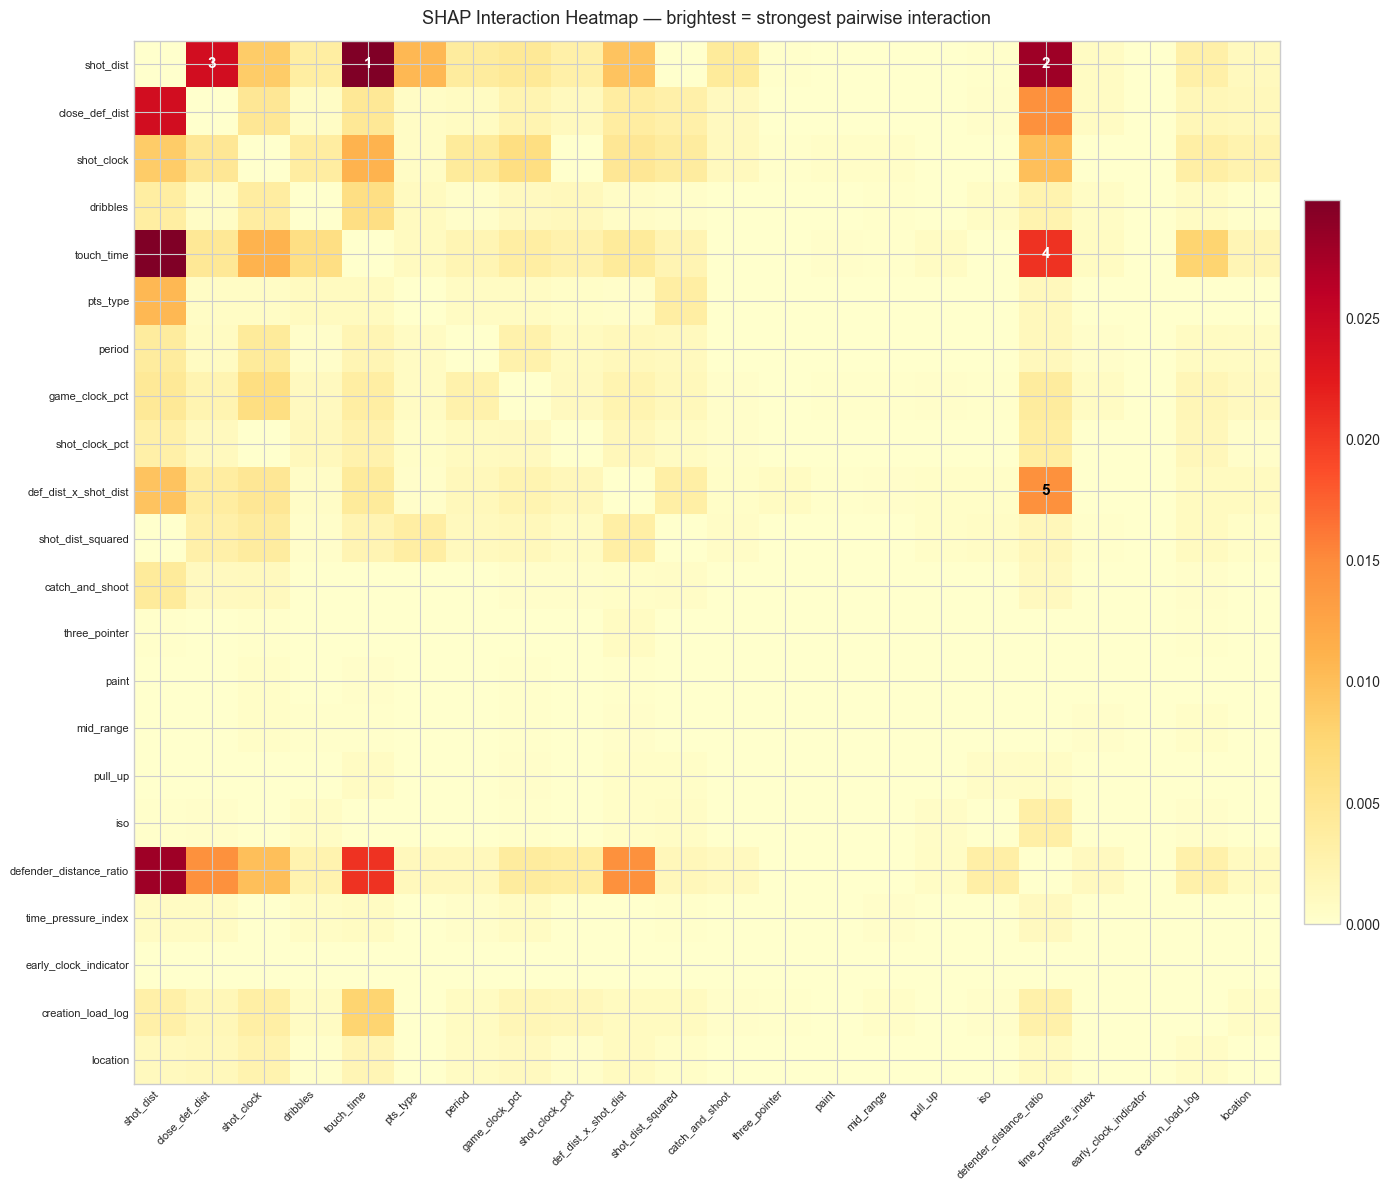

Saved -> models/shap_interaction_heatmap.png


In [ ]:
rng_heatmap = np.random.default_rng(42)
sample_3k   = rng_heatmap.choice(len(X_test), size=3_000, replace=False)
X_sample_3k = X_test.iloc[sample_3k]

print("Computing SHAP interaction values (this may take 1-2 min)...")
shap_interaction = explainer.shap_interaction_values(X_sample_3k)
print(f"Interaction values shape: {shap_interaction.shape}")

mean_abs = np.mean(np.abs(shap_interaction), axis=0)
np.fill_diagonal(mean_abs, 0)

# top-5 off-diagonal pairs (upper triangle only)
n     = len(feature_columns)
upper = [(mean_abs[i, j], i, j) for i in range(n) for j in range(i + 1, n)]
top5  = sorted(upper, reverse=True)[:5]

fig_hm, ax_hm = plt.subplots(figsize=(14, 12))
im = ax_hm.imshow(mean_abs, cmap="YlOrRd", aspect="auto")
plt.colorbar(im, ax=ax_hm, fraction=0.03, pad=0.02)

ax_hm.set_xticks(range(n))
ax_hm.set_yticks(range(n))
ax_hm.set_xticklabels(feature_columns, rotation=45, ha="right", fontsize=8)
ax_hm.set_yticklabels(feature_columns, fontsize=8)

vmax = mean_abs.max()
for rank, (val, row, col) in enumerate(top5, 1):
    txt_color = "white" if val > vmax * 0.65 else "black"
    ax_hm.text(
        col, row, str(rank),
        ha="center", va="center",
        fontsize=11, fontweight="bold",
        color=txt_color,
    )

ax_hm.set_title(
    "SHAP Interaction Heatmap — brightest = strongest pairwise interaction",
    fontsize=13,
    pad=12,
)
plt.tight_layout()
plt.savefig("models/shap_interaction_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> models/shap_interaction_heatmap.png")

Across the SHAP beeswarm, interaction heatmap, and dependence plots, a clear pattern emerges: shot quality is shaped less by single variables alone and more by how factors like shot distance, defensive pressure, shot creation, and timing work together. The model suggests that relative openness (especially defender distance ratio) carries strong predictive power, often adding information beyond raw shot location by itself, while distance, shot clock pressure, and touch time show important nonlinear patterns and thresholds. The interaction results also show that factors like distance and defense, or shot creation and pressure, often build on each other rather than affecting shots separately, reinforcing that shot value depends heavily on context. Overall, these results support the project’s main idea that evaluating shot quality requires looking at the full game situation around a shot, rather than relying on simple rules like “closer shots are always better.”